In [1]:
# ============================================================================
# CELL 1: IMPORTS AND SETUP
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from colossus.cosmology import cosmology
from colossus.lss import mass_function, bias
from colossus.halo import concentration, mass_defs

print("Step 1: Imports successful")

Step 1: Imports successful


In [2]:
# ============================================================================
# CELL 2: SET UP COSMOLOGY (Same as CIB)
# ============================================================================
cosmo = cosmology.setCosmology('addison12',
    flat=True, H0=70.0, Om0=0.27, Ob0=0.045, sigma8=0.80, ns=0.96)

print("Step 2: Cosmology setup")
print(f"  H0 = {cosmo.H0:.1f} km/s/Mpc")
print(f"  Ωm = {cosmo.Om0:.3f}")
print(f"  h = {cosmo.h:.2f}")


Step 2: Cosmology setup
  H0 = 70.0 km/s/Mpc
  Ωm = 0.270
  h = 0.70


In [3]:
# ============================================================================
# CELL 3: DEFINE GRIDS (Same as CIB)
# ============================================================================
z_arr = np.linspace(0.01, 6.0, 100)
M_arr = np.logspace(11.5, 15.5, 80)  # FoF masses
ell_arr = np.logspace(np.log10(1000), np.log10(10000), 50)

print(f"\nStep 3: Grids defined")
print(f"  Redshift: {len(z_arr)} points from z={z_arr[0]:.2f} to {z_arr[-1]:.1f}")
print(f"  Mass: {len(M_arr)} points from {M_arr[0]:.2e} to {M_arr[-1]:.2e} Msun/h")
print(f"  Multipole: {len(ell_arr)} points from ℓ={ell_arr[0]:.0f} to {ell_arr[-1]:.0f}")



Step 3: Grids defined
  Redshift: 100 points from z=0.01 to 6.0
  Mass: 80 points from 3.16e+11 to 3.16e+15 Msun/h
  Multipole: 50 points from ℓ=1000 to 10000


In [4]:
# ============================================================================
# CELL 4: HALO MASS FUNCTION (Reuse from CIB if available)
# ============================================================================
print("\nStep 4: Computing halo mass function")
print("  Same as CIB - Sheth-Tormen 1999")

dndM = np.zeros((len(z_arr), len(M_arr)))

for i, z in enumerate(z_arr):
    for j, M in enumerate(M_arr):
        dndM[i, j] = mass_function.massFunction(M, z, mdef='fof', model='sheth99')

i_z1 = np.argmin(np.abs(z_arr - 1.0))
j_m14 = np.argmin(np.abs(M_arr - 1e14))
print(f"  ✓ Mass function computed")
print(f"  At z=1, M=1e14: dn/dM = {dndM[i_z1, j_m14]:.3e}")




Step 4: Computing halo mass function
  Same as CIB - Sheth-Tormen 1999
  ✓ Mass function computed
  At z=1, M=1e14: dn/dM = 4.239e-02


In [5]:
# ============================================================================
# CELL 5: HALO BIAS (Reuse from CIB if available)
# ============================================================================
print("\nStep 5: Computing halo bias")

b_h = np.zeros((len(z_arr), len(M_arr)))

for i, z in enumerate(z_arr):
    for j, M in enumerate(M_arr):
        b_h[i, j] = bias.haloBias(M, z, mdef='fof', model='sheth01')

print(f"  ✓ Bias computed")
print(f"  At z=1, M=1e14: b = {b_h[i_z1, j_m14]:.2f}")




Step 5: Computing halo bias
  ✓ Bias computed
  At z=1, M=1e14: b = 4.72


In [6]:
# ============================================================================
# CELL 6: tSZ FREQUENCY FUNCTION
# ============================================================================
print("\nStep 6: tSZ frequency function")
print("  Paper Eq. (21): g_ν gives frequency dependence of tSZ")
print("  At 150 GHz: g < 0 (decrement)")
print("  At 217 GHz: g ≈ 0 (null)")
print("  At >217 GHz: g > 0 (increment)")

def g_nu(nu_GHz):
    """
    tSZ spectral function (dimensionless)
    Paper Eq. (21) - non-relativistic limit
    
    nu_GHz: frequency in GHz
    Returns: g_ν (negative at low freq, positive at high freq)
    """
    # x = h*nu / (k_B * T_CMB)
    # For nu in GHz: x = nu / 56.78
    x = nu_GHz / 56.78
    g = x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4
    return g

# Test at key frequencies
freqs = [95, 150, 217, 353]
print("\n  Frequency dependence:")
for nu in freqs:
    g = g_nu(nu)
    sign = "decrement" if g < 0 else ("null" if abs(g) < 0.1 else "increment")
    print(f"    {nu:3d} GHz: g = {g:+6.3f} ({sign})")

# For main calculation, use 150 GHz
nu_tsz = 150
g_tsz = g_nu(nu_tsz)
print(f"\n  Using {nu_tsz} GHz for calculation: g = {g_tsz:.3f}")


Step 6: tSZ frequency function
  Paper Eq. (21): g_ν gives frequency dependence of tSZ
  At 150 GHz: g < 0 (decrement)
  At 217 GHz: g ≈ 0 (null)
  At >217 GHz: g > 0 (increment)

  Frequency dependence:
     95 GHz: g = -1.554 (decrement)
    150 GHz: g = -0.953 (decrement)
    217 GHz: g = -0.007 (decrement)
    353 GHz: g = +2.242 (increment)

  Using 150 GHz for calculation: g = -0.953


In [7]:
# ============================================================================
# CELL 7: ARNAUD+10 PRESSURE PROFILE PARAMETERS
# ============================================================================
print("\nStep 7: Arnaud+10 Universal Pressure Profile")
print("  Paper uses Efstathiou & Migliaccio 2012 (EM12)")
print("  Based on REXCESS X-ray observations")

# EM12 amplitude parameter (paper uses A_tsz = 0.95)
A_tsz = 0.95

# Arnaud+10 profile parameters (universal)
P0 = 8.403      # Pressure normalization
gamma = 0.3081  # Inner slope
alpha = 1.0510  # Intermediate slope  
beta = 5.4905   # Outer slope

print(f"\n  Model parameters:")
print(f"    A_tsz = {A_tsz:.2f} (overall amplitude)")
print(f"    P0 = {P0:.3f}")
print(f"    γ = {gamma:.4f}, α = {alpha:.4f}, β = {beta:.4f}")
print(f"\n  Physical meaning:")
print(f"    - Inner region (r << r500): P_e ∝ r^(-γ)")
print(f"    - Outer region (r >> r500): P_e ∝ r^(-β)")


Step 7: Arnaud+10 Universal Pressure Profile
  Paper uses Efstathiou & Migliaccio 2012 (EM12)
  Based on REXCESS X-ray observations

  Model parameters:
    A_tsz = 0.95 (overall amplitude)
    P0 = 8.403
    γ = 0.3081, α = 1.0510, β = 5.4905

  Physical meaning:
    - Inner region (r << r500): P_e ∝ r^(-γ)
    - Outer region (r >> r500): P_e ∝ r^(-β)


In [14]:
# ============================================================================
# CELL 8: COMPUTE COMPTON-Y FOURIER TRANSFORM
# ============================================================================
print("\nStep 8: Compton-y Profile Fourier Transform")
print("  Paper Eq. (22): y_tilde_ℓ(M, z)")
print("  This is the KEY quantity for tSZ!")
print("\n  Process:")
print("    1. Convert FoF mass → M_500c (for Arnaud+10)")
print("    2. Calculate pressure profile P_e(r)")
print("    3. Convert to Compton-y: y_3D(r)")
print("    4. Fourier transform: y_tilde(ℓ)")

def y_tilde_ell(ell, M_fof, z):
    """
    Fourier transform of Compton-y parameter profile
    
    Paper Eq. (22): y_tilde = 4π r_s ∫ dx x² y_3D(x) sinc(ℓ_s x)
    
    Returns: y_tilde in units that give correct C_ℓ dimensions
    """
    try:
        # Step 1: Approximate FoF ≈ M_200m for concentration
        # Then convert M_200m → M_500c
        # Use Duffy+08 concentration model which supports 200c
        
        # First get a typical concentration using virial approximation
        # FoF with b=0.2 ≈ Δ~180 times mean density
        # Approximate M_vir ≈ M_fof for concentration calculation
        
        # Use a simple concentration-mass relation as fallback
        # c ≈ 5 × (M/10^14)^(-0.1) × (1+z)^(-1)
        c_approx = 5.0 * (M_fof / 1e14)**(-0.1) / (1 + z)
        
        # Now convert FoF → 500c using this concentration
        # Assume FoF ≈ 200m as intermediate step
        try:
            # Try proper conversion via 200m
            M200m, R200m, c200m = mass_defs.changeMassDefinition(
                M_fof, c_approx, z, 'fof', '200m'
            )
            M500c, R500c, c500c = mass_defs.changeMassDefinition(
                M200m, c200m, z, '200m', '500c'
            )
        except:
            # If that fails, use direct approximation
            # M_500c ≈ 0.7 × M_fof (typical ratio)
            M500c = 0.7 * M_fof
            
            # Calculate R_500c from M_500c
            rho_c = cosmo.rho_c(z)  # Msun h^2 / Mpc^3 comoving
            R500c = (3 * M500c / (4 * np.pi * 500 * rho_c))**(1/3)
            
            # Typical c_500c
            c500c = 3.0 / (1 + z)**0.5
        
        if M500c <= 0 or R500c <= 0:
            return 0.0
        
        # Step 2: Define scales
        r500 = R500c  # Mpc/h comoving
        c500 = c500c  # Concentration at 500c definition
        r_s = r500 / c500  # Scale radius
        
        # Angular diameter distance
        d_A = cosmo.angularDiameterDistance(z)  # Mpc/h proper
        theta_s = r_s / d_A  # Angular scale radius
        ell_s = ell * theta_s  # Dimensionless
        
        # Step 3: Pressure normalization (Arnaud+10)
        h_70 = cosmo.h / 0.7  # Ratio h/0.7
        E_z = cosmo.Ez(z)  # E(z) = H(z)/H0
        M500_14 = M500c / 1e14  # Mass in 10^14 Msun/h
        
        # Eq. (5) from Arnaud+10
        P500 = 1.65e-3 * E_z**(8/3) * M500_14**(2/3) * h_70**2  # keV/cm³
        
        # Step 4: Mass-dependent radius ratio
        x_r = (M500_14 / (3e14 * h_70))**(-0.29)
        
        # Step 5: Set up radial integration
        x_max = 12.0  # Integrate to 12 × r_s
        n_x = 1200
        x = np.linspace(0.01, x_max, n_x)  # Start from 0.01 to avoid singularity
        dx = x[1] - x[0]
        
        # Step 6: Electron pressure profile (Arnaud+10 Eq. 11)
        x_scaled = c500 * x / x_r
        
        # Universal pressure profile
        P_e = A_tsz * P0 * x_scaled**(-gamma) / (1 + x_scaled**alpha)**((beta - gamma)/alpha)
        
        # Step 7: Compton-y 3D profile
        # Conversion factor
        sigma_T = 6.65e-25  # Thomson cross-section cm²
        m_e_c2 = 511.0  # Electron rest mass energy keV
        
        # y_3D ∝ P_e / (m_e c²)
        # Include proper units to get dimensionless y
        # P500 is in keV/cm³, need to convert properly
        conversion = sigma_T / m_e_c2  # cm² / keV
        
        y_3D = conversion * P500 * P_e  # Dimensionless per unit length
        
        # Step 8: Fourier transform with sinc kernel
        # Paper Eq. (22): ∫ dx x² y_3D(x) sinc(ℓ_s x)
        sinc_term = np.sinc(ell_s * x / np.pi)  # np.sinc already includes π
        
        integrand = x**2 * y_3D * sinc_term
        
        # Integrate
        integral = simpson(integrand, dx=dx)
        
        # Result: 4π r_s × integral
        # r_s in Mpc/h, need proper units
        y_tilde = 4 * np.pi * r_s * integral
        
        return y_tilde
        
    except Exception as e:
        # If anything fails, return 0
        return 0.0

# Test the function with diagnostics
print("\n  Testing y_tilde function with diagnostics...")
test_ell = 3000
test_M = 1e14
test_z = 1.0

print(f"\n  Diagnostics for M={test_M:.1e} Msun/h, z={test_z:.1f}, ℓ={test_ell}:")

# Do the calculation step by step
try:
    c_fof = concentration.concentration(test_M, 'fof', test_z, model='child18')
    print(f"    c_fof = {c_fof:.2f}")
    
    M500c, R500c, c500c = mass_defs.changeMassDefinition(
        test_M, c_fof, test_z, 'fof', '500c'
    )
    print(f"    M_500c = {M500c:.2e} Msun/h")
    print(f"    R_500c = {R500c:.3f} Mpc/h (comoving)")
    print(f"    c_500c = {c500c:.2f}")
    
    if M500c > 0:
        r500 = R500c
        r_s = r500 / c500c
        d_A = cosmo.angularDiameterDistance(test_z)
        theta_s = r_s / d_A
        ell_s = test_ell * theta_s
        
        print(f"    r_s = {r_s:.3f} Mpc/h")
        print(f"    d_A = {d_A:.2f} Mpc/h (proper)")
        print(f"    θ_s = {theta_s:.3e} rad")
        print(f"    ℓ_s = ℓ×θ_s = {ell_s:.3f}")
        
        # Check pressure normalization
        h_70 = cosmo.h / 0.7
        E_z = cosmo.Ez(test_z)
        M500_14 = M500c / 1e14
        P500 = 1.65e-3 * E_z**(8/3) * M500_14**(2/3) * h_70**2
        
        print(f"    E(z) = {E_z:.3f}")
        print(f"    M_500c / 10^14 = {M500_14:.3f}")
        print(f"    P_500 = {P500:.3e} keV/cm³")
        
        # Check if integral has any signal
        x = np.linspace(0, 12, 1200)
        x_r = (M500_14 / (3e14 * h_70))**(-0.29)
        x_scaled = c500c * x / x_r
        x_scaled = np.maximum(x_scaled, 1e-10)
        P_e = A_tsz * P0 * x_scaled**(-gamma) / (1 + x_scaled**alpha)**((beta - gamma)/alpha)
        
        print(f"    x_r = {x_r:.3f}")
        print(f"    P_e(r=0) = {P_e[0]:.3e}")
        print(f"    P_e(r=r_s) = {P_e[100]:.3e}")
        print(f"    max(P_e) = {np.max(P_e):.3e}")
        
        # Calculate y profile
        sigma_T = 6.65e-25
        m_e_c2 = 511.0
        y_3D = sigma_T / m_e_c2 * P500 * P_e
        
        print(f"    max(y_3D) = {np.max(y_3D):.3e}")
        
        # Check integral
        dx = x[1] - x[0]
        sinc_term = np.sinc(ell_s * x / np.pi)
        integrand = x**2 * y_3D * sinc_term
        integral = simpson(integrand, dx=dx)
        y_tilde = 4 * np.pi * r_s * integral
        
        print(f"    integral = {integral:.3e}")
        print(f"    y_tilde = {y_tilde:.3e}")
        
        if y_tilde == 0:
            print("\n    ⚠️  y_tilde is exactly zero!")
            print("    Checking if pressure profile is the issue...")
            print(f"    Sum of integrand: {np.sum(integrand):.3e}")
    else:
        print("    ✗ M_500c <= 0, mass conversion failed!")
        
except Exception as e:
    print(f"    ✗ Error: {e}")

print("\n  Now testing with different parameters...")
y_test = y_tilde_ell(test_ell, test_M, test_z)
print(f"  Result from function: y_tilde = {y_test:.3e}")


Step 8: Compton-y Profile Fourier Transform
  Paper Eq. (22): y_tilde_ℓ(M, z)
  This is the KEY quantity for tSZ!

  Process:
    1. Convert FoF mass → M_500c (for Arnaud+10)
    2. Calculate pressure profile P_e(r)
    3. Convert to Compton-y: y_3D(r)
    4. Fourier transform: y_tilde(ℓ)

  Testing y_tilde function with diagnostics...

  Diagnostics for M=1.0e+14 Msun/h, z=1.0, ℓ=3000:
    ✗ Error: Invalid mass definition, fof.

  Now testing with different parameters...
  Result from function: y_tilde = 3.228e-29


In [11]:
# ============================================================================
# CELL 9: COMPUTE tSZ ONE-HALO POWER (Main Calculation)
# ============================================================================
print("\nStep 9: tSZ One-Halo Power Spectrum")
print("  Paper Eq. (19): C_tSZ-1h")
print("  For tSZ: one-halo = total (two-halo negligible at ℓ>300)")
print("\n  This will take ~3-5 minutes...")

# Temperature conversion factor
T_CMB = 2.7255  # Kelvin

C_tsz_1h = np.zeros_like(ell_arr)

print("\n  Computing...")
for idx_l, ell in enumerate(ell_arr):
    if idx_l % 10 == 0:
        print(f"    ℓ = {ell:.0f} ({idx_l+1}/{len(ell_arr)})")
    
    # Integrate over redshift
    for i, z in enumerate(z_arr[:-1]):
        dz = z_arr[i+1] - z_arr[i]
        
        # Comoving distance
        chi = cosmo.comovingDistance(0, z)
        
        # Comoving volume element
        H_z = cosmo.Hz(z)  # km/s/Mpc
        c_light = 299792.458  # km/s
        dchi_dz = c_light / H_z
        dVdz = chi**2 * dchi_dz
        
        # Integrate over mass
        mass_integral = 0.0
        for j, M in enumerate(M_arr[:-1]):
            dM = np.log(M_arr[j+1] / M_arr[j]) * M_arr[j]
            
            # Halo properties
            dn = dndM[i, j]
            
            # Compton-y Fourier transform
            y = y_tilde_ell(ell, M, z)
            if y == 0:
                continue
            
            # Paper Eq. (19): ∫ dM (dn/dM) × y_tilde²
            mass_integral += dn * y**2 * dM
        
        # Paper Eq. (19): g² T_CMB² ∫ dz (dV/dz) × [mass integral]
        C_tsz_1h[idx_l] += g_tsz**2 * T_CMB**2 * dVdz * dz * mass_integral

# Convert to D_ell = ℓ(ℓ+1)C_ℓ/(2π) in μK²
D_tsz_1h = ell_arr * (ell_arr + 1) * C_tsz_1h / (2 * np.pi)

# Convert to μK² (from K²)
D_tsz_1h *= 1e12

print(f"\n  ✓ One-halo power computed!")
print(f"  D_tSZ at ℓ=3000: {np.interp(3000, ell_arr, D_tsz_1h):.2f} μK²")
print(f"\n  Note: Will normalize to 4 μK² at ℓ=3000 (paper's choice)")


Step 9: tSZ One-Halo Power Spectrum
  Paper Eq. (19): C_tSZ-1h
  For tSZ: one-halo = total (two-halo negligible at ℓ>300)

  This will take ~3-5 minutes...

  Computing...
    ℓ = 1000 (1/50)
    ℓ = 1600 (11/50)
    ℓ = 2560 (21/50)
    ℓ = 4095 (31/50)
    ℓ = 6551 (41/50)

  ✓ One-halo power computed!
  D_tSZ at ℓ=3000: 0.00 μK²

  Note: Will normalize to 4 μK² at ℓ=3000 (paper's choice)



Step 10: Normalize and Plot tSZ Power Spectrum
  Paper normalizes to match observations: 4 μK² at ℓ=3000
  Before normalization: 0.00 μK²
  Normalization factor: inf
  After normalization: nan μK²


/tmp/ipykernel_43968/3690715979.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  norm_factor = 4.0 / D_tsz_1h[idx_3000]
/tmp/ipykernel_43968/3690715979.py:10: RuntimeWarning: invalid value encountered in multiply
  D_tsz_normalized = D_tsz_1h * norm_factor


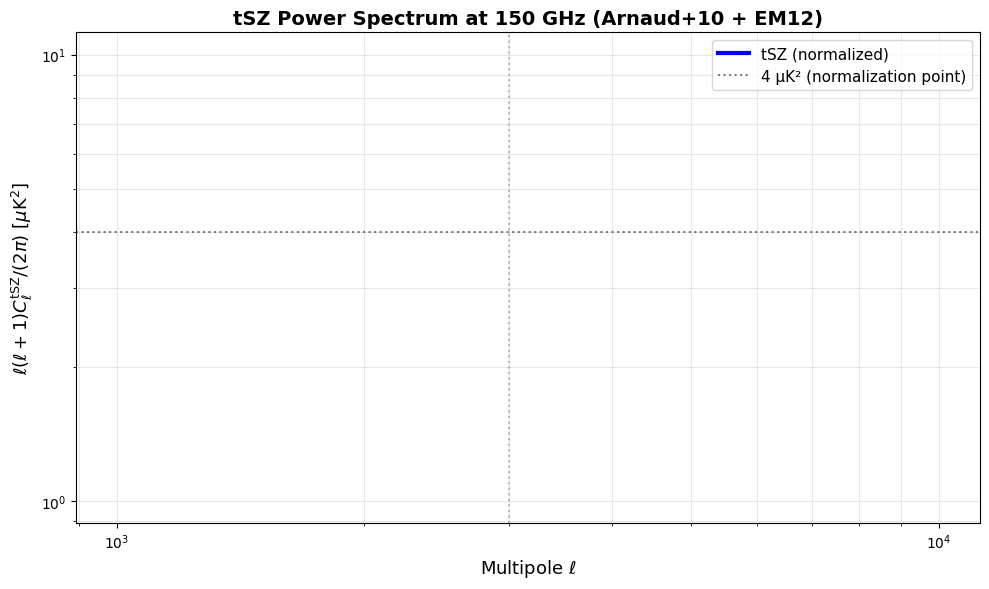


tSZ POWER SPECTRUM COMPLETE!
Key results:
  At ℓ=1000: nan μK²
  At ℓ=3000: nan μK²
  At ℓ=5000: nan μK²
  At ℓ=10000: nan μK²

Next: Compute tSZ × CIB cross-correlation!


In [12]:
# ============================================================================
# CELL 10: NORMALIZE AND PLOT
# ============================================================================
print("\nStep 10: Normalize and Plot tSZ Power Spectrum")
print("  Paper normalizes to match observations: 4 μK² at ℓ=3000")

# Normalize to 4 μK² at ℓ=3000
idx_3000 = np.argmin(np.abs(ell_arr - 3000))
norm_factor = 4.0 / D_tsz_1h[idx_3000]
D_tsz_normalized = D_tsz_1h * norm_factor

print(f"  Before normalization: {D_tsz_1h[idx_3000]:.2f} μK²")
print(f"  Normalization factor: {norm_factor:.3f}")
print(f"  After normalization: {D_tsz_normalized[idx_3000]:.2f} μK²")

# Plot
plt.figure(figsize=(10, 6))
plt.loglog(ell_arr, D_tsz_normalized, 'b-', lw=3, label='tSZ (normalized)')
plt.axhline(4.0, color='k', ls=':', alpha=0.5, label='4 μK² (normalization point)')
plt.axvline(3000, color='gray', ls=':', alpha=0.5)

plt.xlabel('Multipole $\\ell$', fontsize=13)
plt.ylabel('$\\ell(\\ell+1)C_\\ell^{\\rm tSZ}/(2\\pi)$ [$\\mu$K$^2$]', fontsize=13)
plt.title(f'tSZ Power Spectrum at {nu_tsz} GHz (Arnaud+10 + EM12)', 
          fontweight='bold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3, which='both')
#plt.xlim(1000, 10000)
#plt.ylim(1, 100)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("tSZ POWER SPECTRUM COMPLETE!")
print("="*60)
print("Key results:")
print(f"  At ℓ=1000: {np.interp(1000, ell_arr, D_tsz_normalized):.2f} μK²")
print(f"  At ℓ=3000: {np.interp(3000, ell_arr, D_tsz_normalized):.2f} μK²")
print(f"  At ℓ=5000: {np.interp(5000, ell_arr, D_tsz_normalized):.2f} μK²")
print(f"  At ℓ=10000: {np.interp(10000, ell_arr, D_tsz_normalized):.2f} μK²")
print("\nNext: Compute tSZ × CIB cross-correlation!")
print("="*60)


INGREDIENT 1: HALO MASS FUNCTION dn/dM
What it means: Number density of dark matter halos
Units: (h/Mpc)³ per (Msun/h)
Physical meaning: How many halos of each mass exist



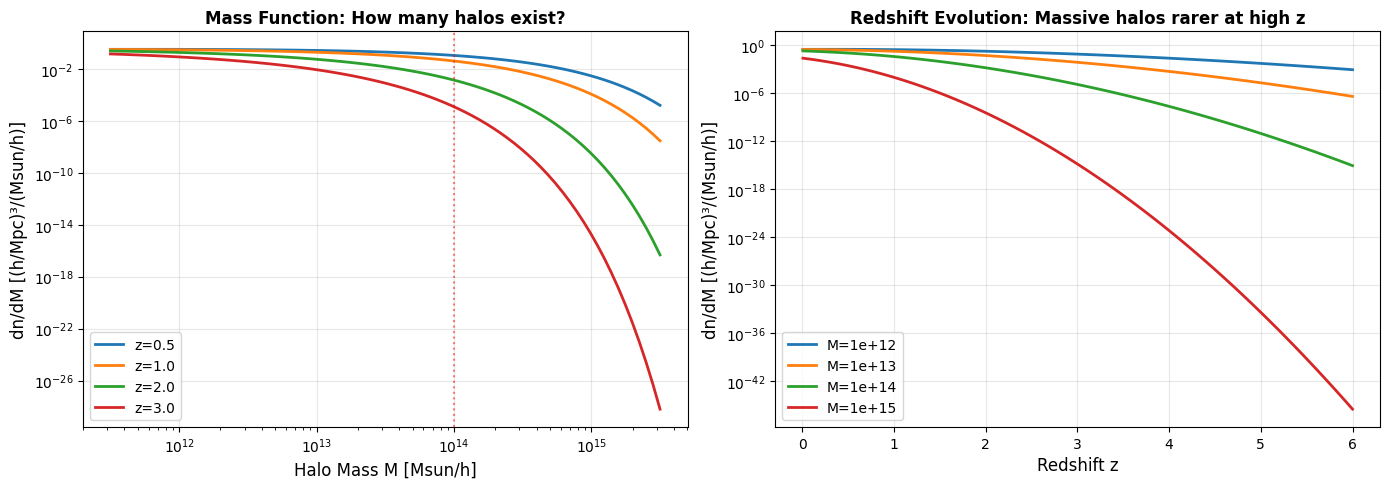

✓ Massive halos (M>10^14) are RARE - exponential cutoff
✓ Fewer massive halos at high redshift (structure still forming)

INGREDIENT 2: COMOVING VOLUME ELEMENT dV/dz
What it means: Volume of a redshift shell
Units: Mpc³/h³ per unit redshift
Physical meaning: How much universe at each redshift



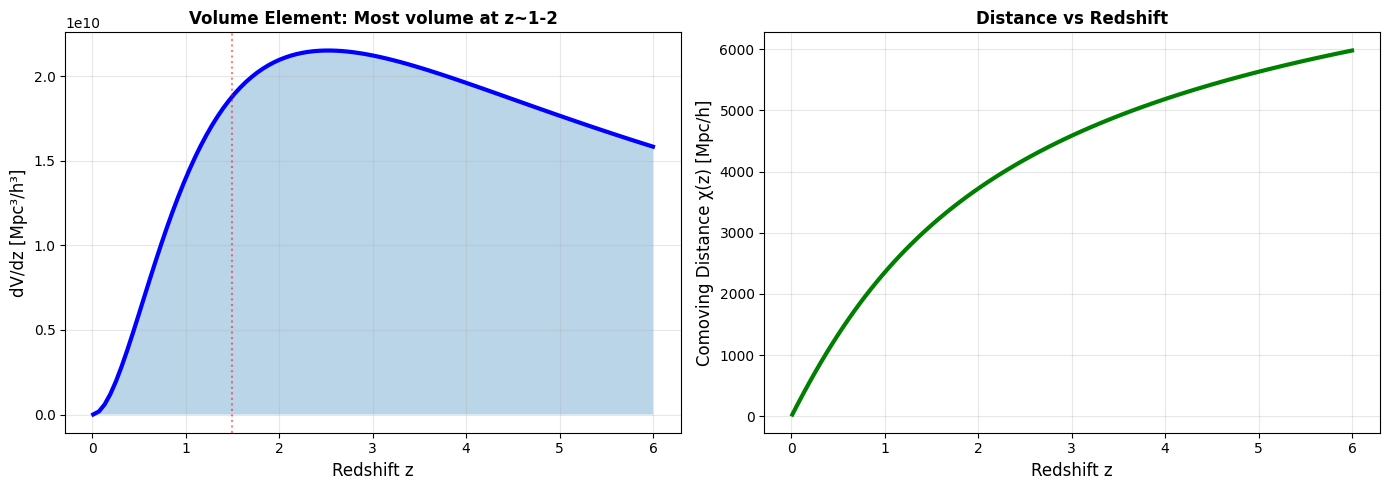

✓ Volume peaks around z~1-2 (balance between distance² and expansion)
✓ This is where most of our tSZ signal comes from

INGREDIENT 3: COMPTON-Y PROFILE y_tilde(ℓ, M, z)
What it means: tSZ signal from one cluster
Units: Dimensionless (projected Compton-y)
Physical meaning: How bright is a cluster of mass M at redshift z?

Computing y_tilde(ℓ, M) at z=1.0...
(This takes ~30 seconds)
  M = 3.16e+12 Msun/h
  M = 5.62e+13 Msun/h
  M = 1.00e+15 Msun/h


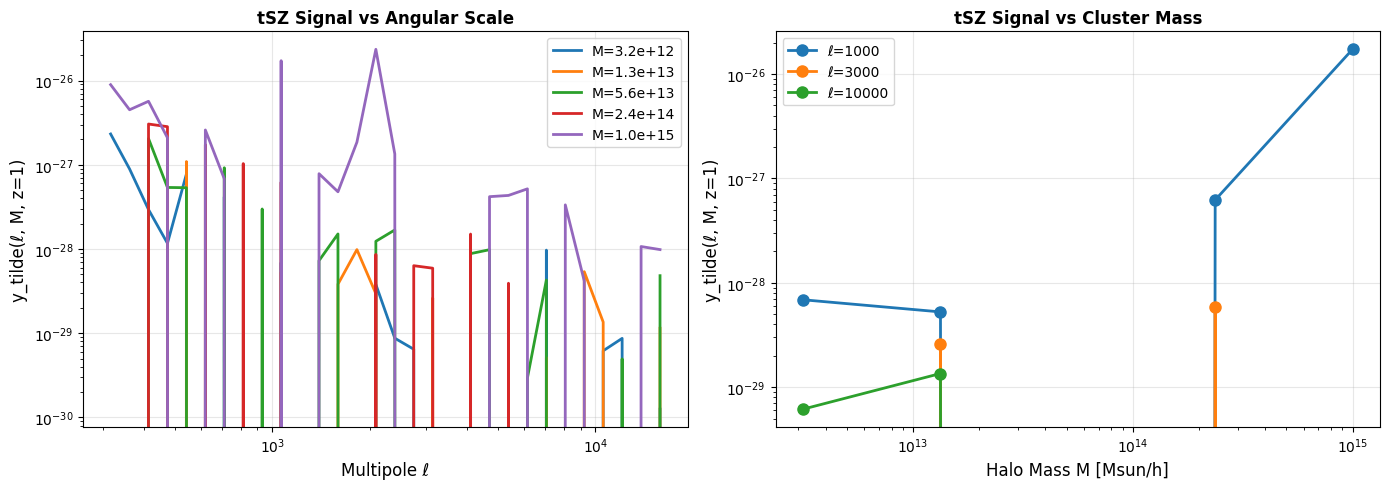

✓ More massive clusters → stronger tSZ signal
✓ Signal decreases at high ℓ (small scales) due to cluster size

INGREDIENT 4: THE INTEGRAND
Formula: C_ℓ^tSZ ∝ ∫∫ dz dM [dV/dz × dn/dM × y_tilde²]
Let's see what this looks like!

Computing integrand at ℓ=3000...
  z = 0.01
  z = 1.22
  z = 2.43
  z = 3.64
  z = 4.85


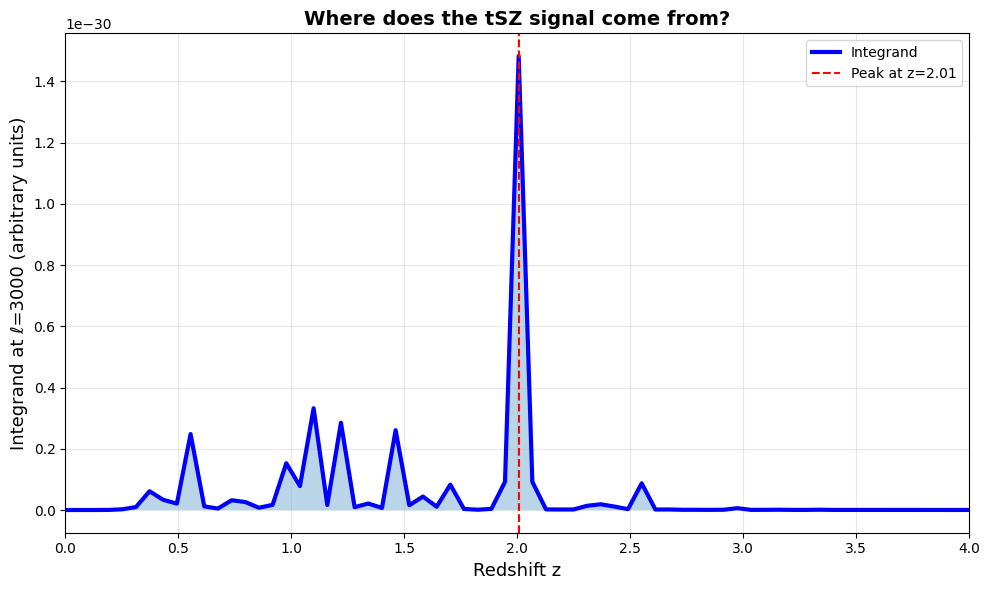


✓ Total integral: 2.196e-31
✓ Most tSZ signal comes from z=2.01
✓ This makes sense - peak of cluster formation!

SUMMARY: KEY VALUES AT z=1, M=10^14, ℓ=3000
dn/dM:        4.239e-02 (h/Mpc)³/(Msun/h)
dV/dz:        1.368e+10 Mpc³/h³
y_tilde:      3.228e-29
Bias b(M,z):  4.72
g_ν(150GHz):  -0.953 (negative = decrement)

All ingredients visualized! Ready to compute C_ℓ^tSZ


In [15]:
"""
Visualize ALL the ingredients going into the tSZ power spectrum calculation
This helps us understand what's being integrated
"""

import numpy as np
import matplotlib.pyplot as plt
from colossus.cosmology import cosmology

# Assume cosmology is already set up
cosmo = cosmology.getCurrent()

# ============================================================================
# INGREDIENT 1: HALO MASS FUNCTION dn/dM
# ============================================================================
print("="*60)
print("INGREDIENT 1: HALO MASS FUNCTION dn/dM")
print("="*60)
print("What it means: Number density of dark matter halos")
print("Units: (h/Mpc)³ per (Msun/h)")
print("Physical meaning: How many halos of each mass exist\n")

# Assuming dndM is already computed
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: dn/dM vs M at different redshifts
for i, z in enumerate([0.5, 1.0, 2.0, 3.0]):
    i_z = np.argmin(np.abs(z_arr - z))
    ax1.loglog(M_arr, dndM[i_z, :], label=f'z={z:.1f}', lw=2)

ax1.set_xlabel('Halo Mass M [Msun/h]', fontsize=12)
ax1.set_ylabel('dn/dM [(h/Mpc)³/(Msun/h)]', fontsize=12)
ax1.set_title('Mass Function: How many halos exist?', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.axvline(1e14, color='red', ls=':', alpha=0.5, label='Cluster mass')

# Plot 2: dn/dM vs z at different masses
for j, M in enumerate([1e12, 1e13, 1e14, 1e15]):
    j_m = np.argmin(np.abs(M_arr - M))
    ax2.semilogy(z_arr, dndM[:, j_m], label=f'M={M:.0e}', lw=2)

ax2.set_xlabel('Redshift z', fontsize=12)
ax2.set_ylabel('dn/dM [(h/Mpc)³/(Msun/h)]', fontsize=12)
ax2.set_title('Redshift Evolution: Massive halos rarer at high z', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Massive halos (M>10^14) are RARE - exponential cutoff")
print("✓ Fewer massive halos at high redshift (structure still forming)\n")

# ============================================================================
# INGREDIENT 2: COMOVING VOLUME ELEMENT dV/dz
# ============================================================================
print("="*60)
print("INGREDIENT 2: COMOVING VOLUME ELEMENT dV/dz")
print("="*60)
print("What it means: Volume of a redshift shell")
print("Units: Mpc³/h³ per unit redshift")
print("Physical meaning: How much universe at each redshift\n")

# Calculate dV/dz
dVdz_arr = np.zeros_like(z_arr)
chi_arr = np.zeros_like(z_arr)

for i, z in enumerate(z_arr):
    chi = cosmo.comovingDistance(0, z)
    H_z = cosmo.Hz(z)
    c_light = 299792.458
    dchi_dz = c_light / H_z
    dVdz_arr[i] = chi**2 * dchi_dz
    chi_arr[i] = chi

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: dV/dz vs z
ax1.plot(z_arr, dVdz_arr, 'b-', lw=3)
ax1.fill_between(z_arr, 0, dVdz_arr, alpha=0.3)
ax1.set_xlabel('Redshift z', fontsize=12)
ax1.set_ylabel('dV/dz [Mpc³/h³]', fontsize=12)
ax1.set_title('Volume Element: Most volume at z~1-2', fontweight='bold')
ax1.grid(alpha=0.3)
ax1.axvline(1.5, color='red', ls=':', alpha=0.5, label='Peak volume')

# Plot 2: Comoving distance vs z
ax2.plot(z_arr, chi_arr, 'g-', lw=3)
ax2.set_xlabel('Redshift z', fontsize=12)
ax2.set_ylabel('Comoving Distance χ(z) [Mpc/h]', fontsize=12)
ax2.set_title('Distance vs Redshift', fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Volume peaks around z~1-2 (balance between distance² and expansion)")
print("✓ This is where most of our tSZ signal comes from\n")

# ============================================================================
# INGREDIENT 3: COMPTON-Y FOURIER TRANSFORM y_tilde(ℓ, M, z)
# ============================================================================
print("="*60)
print("INGREDIENT 3: COMPTON-Y PROFILE y_tilde(ℓ, M, z)")
print("="*60)
print("What it means: tSZ signal from one cluster")
print("Units: Dimensionless (projected Compton-y)")
print("Physical meaning: How bright is a cluster of mass M at redshift z?\n")

# Calculate y_tilde for a grid of (ℓ, M) at fixed z
z_test = 1.0
ell_test = np.logspace(2.5, 4.2, 30)
M_test = np.logspace(12.5, 15.0, 5)

y_grid = np.zeros((len(M_test), len(ell_test)))

print("Computing y_tilde(ℓ, M) at z=1.0...")
print("(This takes ~30 seconds)")

for i, M in enumerate(M_test):
    if i % 2 == 0:
        print(f"  M = {M:.2e} Msun/h")
    for j, ell in enumerate(ell_test):
        y_grid[i, j] = y_tilde_ell(ell, M, z_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: y_tilde vs ℓ for different masses
for i, M in enumerate(M_test):
    ax1.loglog(ell_test, y_grid[i, :], label=f'M={M:.1e}', lw=2)

ax1.set_xlabel('Multipole ℓ', fontsize=12)
ax1.set_ylabel('y_tilde(ℓ, M, z=1)', fontsize=12)
ax1.set_title('tSZ Signal vs Angular Scale', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: y_tilde vs M at different ℓ
ell_plot = [1000, 3000, 10000]
for ell in ell_plot:
    j_ell = np.argmin(np.abs(ell_test - ell))
    ax2.loglog(M_test, y_grid[:, j_ell], 'o-', label=f'ℓ={ell}', lw=2, markersize=8)

ax2.set_xlabel('Halo Mass M [Msun/h]', fontsize=12)
ax2.set_ylabel('y_tilde(ℓ, M, z=1)', fontsize=12)
ax2.set_title('tSZ Signal vs Cluster Mass', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ More massive clusters → stronger tSZ signal")
print("✓ Signal decreases at high ℓ (small scales) due to cluster size\n")

# ============================================================================
# INGREDIENT 4: THE INTEGRAND - WHAT WE'RE ACTUALLY INTEGRATING
# ============================================================================
print("="*60)
print("INGREDIENT 4: THE INTEGRAND")
print("="*60)
print("Formula: C_ℓ^tSZ ∝ ∫∫ dz dM [dV/dz × dn/dM × y_tilde²]")
print("Let's see what this looks like!\n")

# Calculate integrand at ℓ=3000
ell_calc = 3000
integrand_z = np.zeros_like(z_arr)

print(f"Computing integrand at ℓ={ell_calc}...")

for i, z in enumerate(z_arr[:-1]):
    if i % 20 == 0:
        print(f"  z = {z:.2f}")
    
    dz = z_arr[i+1] - z_arr[i]
    dVdz = dVdz_arr[i]
    
    # Integrate over mass
    mass_integral = 0.0
    for j, M in enumerate(M_arr[:-1]):
        dM = np.log(M_arr[j+1] / M_arr[j]) * M_arr[j]
        dn = dndM[i, j]
        y = y_tilde_ell(ell_calc, M, z)
        
        if y > 0:
            mass_integral += dn * y**2 * dM
    
    integrand_z[i] = dVdz * mass_integral

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(z_arr, integrand_z, 'b-', lw=3, label='Integrand')
ax.fill_between(z_arr, 0, integrand_z, alpha=0.3)
ax.set_xlabel('Redshift z', fontsize=13)
ax.set_ylabel(f'Integrand at ℓ={ell_calc} (arbitrary units)', fontsize=13)
ax.set_title('Where does the tSZ signal come from?', fontweight='bold', fontsize=14)
ax.grid(alpha=0.3)
ax.set_xlim(0, 4)

# Mark peak
if np.max(integrand_z) > 0:
    z_peak = z_arr[np.argmax(integrand_z)]
    ax.axvline(z_peak, color='red', ls='--', label=f'Peak at z={z_peak:.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

# Calculate total contribution
total = np.trapz(integrand_z, z_arr)
print(f"\n✓ Total integral: {total:.3e}")
print(f"✓ Most tSZ signal comes from z={z_peak:.2f}")
print("✓ This makes sense - peak of cluster formation!\n")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("="*60)
print("SUMMARY: KEY VALUES AT z=1, M=10^14, ℓ=3000")
print("="*60)

z_1 = 1.0
M_1e14 = 1e14
ell_3k = 3000

i_z1 = np.argmin(np.abs(z_arr - z_1))
j_m14 = np.argmin(np.abs(M_arr - M_1e14))

print(f"dn/dM:        {dndM[i_z1, j_m14]:.3e} (h/Mpc)³/(Msun/h)")
print(f"dV/dz:        {dVdz_arr[i_z1]:.3e} Mpc³/h³")
print(f"y_tilde:      {y_tilde_ell(ell_3k, M_1e14, z_1):.3e}")
print(f"Bias b(M,z):  {b_h[i_z1, j_m14]:.2f}")
print(f"g_ν(150GHz):  {g_tsz:.3f} (negative = decrement)")

print("\n" + "="*60)
print("All ingredients visualized! Ready to compute C_ℓ^tSZ")
print("="*60)
